# Tanaka function
---
Description:

- Optimization (min)
- Multi-objective (2)
- Constraints (2)
---

The equations are given by:

\begin{cases}
      f_{1}\left(\mathbf{x}\right) = x, \\
      f_{2}\left(\mathbf{x}\right) = y, \\
\end{cases}

subject to:

\begin{cases}
      c_{1}\left(\mathbf{x}\right) = x^{2} + y^{2} - 1 - 0.1\cos\left(16 \arctan(x/y) \right) \geq 0, \\
      c_{2}\left(\mathbf{x}\right) = \left(x - 0.5\right)^{2} + \left(y - 0.5\right)^{2} \leq 0.5 \\
\end{cases}

where:

\begin{cases}
      0\le x \le \pi, \\
      0\le y \le \pi. \\
\end{cases}

The constrained Pareto-optimal solutions lie on the boundary of the first constraint. Since the constraint function is periodic and the second constraint function must also be satisfied, not all solutions on the boundary of the first constraint are Pareto-optimal. 

### First we import Python libraries and set up the directory of our code.

In [1]:
import os, sys
import numpy as np
from matplotlib import pyplot as plt

PROJECT_DIR = os.path.abspath('..')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

### Here we import all our custom GA code.

In [2]:
# Import main classes.
from pygenalgo.genome.gene import Gene
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import np_pareto_front, cost_function
from pygenalgo.engines.multi_objective_ga import MultiObjectiveGA, RunConfig

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.blend_crossover import BlendCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.random_mutator import RandomMutator

# Import Selection Operator(s).
from pygenalgo.operators.selection.pareto_front_selector import ParetoFrontSelector

### Define the multi-objective function, which plays also the role of the 'fitness' function.

In addition, we define the 'boundary_xy' which takes the role of the 'random()' method of the Genes. Every 
time we want to 'mutate' a gene this function will be called that returns 'valid', but random values for 
the gene.

In [3]:
# Multi-objective function.
@cost_function(minimize=True)
def fun_tanaka(individual: Chromosome):
        
    # Extract gene values from the chromosome.
    x, y = individual.values()
    
    # Compute each objective function.
    f1, f2 = x, y
    
    # Compute the constraints.
    g1 = min(0.0, x*x + y*y - 1.0 - 0.1*np.cos(16.0 * np.arctan2(x, y)))**2 # >= 0.0
    g2 = max(0.0, (x - 0.5)**2 + (y - 0.5)**2 - 0.5)**2                     # <= 0.0

    # Add up penalty terms.
    penalty: float = g1 + g2

    return (penalty, f1, f2), False
# _end_def_

Here we set the GA parameters, such as number of genes, number of chromosomes, etc.

In [4]:
# Random number generator.
rng = np.random.default_rng()

# Random boundary function:
boundary_x = lambda: rng.uniform(0.0, np.pi)
boundary_y = lambda: rng.uniform(0.0, np.pi)

# Define the number of chromosomes.
n_pop = 500

# Initial population.
population = [Chromosome([Gene(boundary_x(), boundary_x),
                          Gene(boundary_y(), boundary_y)], None, True)
              for _ in range(n_pop)]

# Create the StandardGA object that will carry on the optimization.
test_GA = MultiObjectiveGA(initial_pop=population,
                           fit_func=fun_tanaka,
                           select_op=ParetoFrontSelector(),
                           mutate_op=RandomMutator(),
                           crossx_op=BlendCrossover(lower_lim=[0.0, 0.0],
                                                    upper_lim=[np.pi, np.pi]))

### Optimization process.

Here we call the GA object (either directly, or through the method run()). We set a number of parameter, such as the maximum iterations (i.e. epochs), tolerance for the fitness convergences, etc.

In [5]:
test_GA(config=RunConfig(epochs=500, elitism=True))

09/25/2026 09:21:44 INFO: Initial Avg. Fitness = [-18.8393  -1.5079  -1.5575]
09/25/2026 09:21:51 INFO: Final: Avg. Fitness = [-1.4114 -0.7641 -0.2119]


Elapsed time: 6.955 seconds.


In [6]:
# Declare a list to hold the points.
best_n = []

for p in test_GA.population:
    # Extract the values.
    x, y = p.values()

    # Compute the constraints.
    c1: bool = x**2 + y**2 - 1.0 - 0.1*np.cos(16.0 * np.arctan2(x, y)) >= 0.0
    c2: bool = (x - 0.5)**2 + (y - 0.5)**2 <= 0.5

    # If both constraints are satisfied.
    if c1 and c2:
        # Add them to the list.
        best_n.append((x, y))

# Convert to numpy array.
best_n = np.array(best_n)

# Estimate the pareto front points.
pareto_best_n = np_pareto_front(best_n, "min")

### Compute the true Pareto front.

In [7]:
# Create a list that will hold points that satisfy both constraints.
sample_points = []

# Generate grid sample on [0, pi].
for x in np.linspace(0.0, np.pi, 100):
    
    for y in np.linspace(0.0, np.pi, 100):
        
        # Compute the constraints.
        c1: bool = x**2 + y**2 - 1.0 - 0.1*np.cos(16.0 * np.arctan2(x, y)) >= 0.0
        c2: bool = (x - 0.5)**2 + (y - 0.5)**2 <= 0.5

        # If both constraints are satisfied.
        if c1 and c2:

            # Keep the point in the list.
            sample_points.append((x, y))
# _end_for_

# Convert lists to numpy.
sample_points = np.array(sample_points)

# Estimate the pareto front points.
true_pareto = np_pareto_front(sample_points, "min")

### Visualize the solution on the Pareto plot.

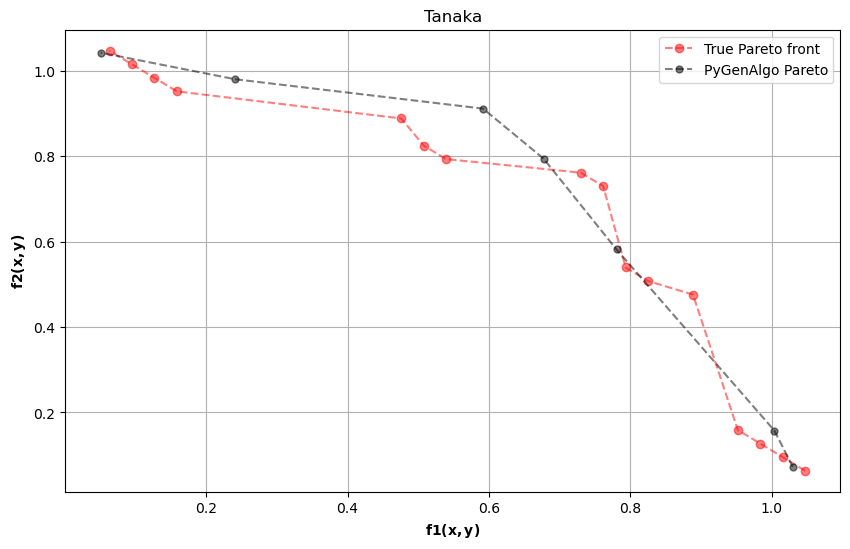

In [8]:
# Create a new figure.
plt.figure(figsize=(10, 6))

# Plot the Pareto front.
plt.plot(true_pareto[:, 0],
         true_pareto[:, 1],
         'ro--', alpha=0.5, label="True Pareto front")

# Plot the Pareto best_n.
plt.plot(pareto_best_n[:, 0],
         pareto_best_n[:, 1], "ko--", alpha=0.5,
         markersize=5, label="PyGenAlgo Pareto")

# Tidy up the plot.
plt.title("Tanaka")
plt.xlabel(r"$\mathbf{f1(x,y)}$")
plt.ylabel(r"$\mathbf{f2(x,y)}$")
plt.legend()
plt.grid(True)

plt.savefig("Tanaka_pareto.pdf", format="pdf", dpi=300)

### End of file